# PromptMap Security Metrics — Multi-Visualisation Notebook
Loads one or more run JSON files from `results/`, parses all metrics into tidy
DataFrames, and renders **7 distinct chart styles** to give you full coverage:
grouped bars, stacked bars, horizontal bars, pie/donut, radar, heat-map, and
timeline scatter.  All bar charts are fixed for overlap / inconsistent width.

In [1]:
import json, math, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
%matplotlib inline


In [2]:

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})

try:
    from IPython.display import display
except Exception:
    def display(x): print(x)

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT = Path.cwd()
for candidate in [ROOT, ROOT.parent]:
    if (candidate / 'results').exists():
        ROOT = candidate
        break

RESULTS_DIR = ROOT / 'results'
GRAPH_DIR   = ROOT / 'graphs' / 'metric_groups'
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

PALETTE = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2',
           '#937860','#DA8BC3','#8C8C8C','#CCB974','#64B5CD']

print('Root:   ', ROOT)
print('Results:', RESULTS_DIR)
print('Graphs: ', GRAPH_DIR)

Root:    d:\BDS\BTP\promptmap
Results: d:\BDS\BTP\promptmap\results
Graphs:  d:\BDS\BTP\promptmap\graphs\metric_groups


In [3]:
def safe_float(v, default=0.0):
    try:
        v = float(v)
        return default if (math.isinf(v) or math.isnan(v)) else v
    except Exception:
        return default

def short_model(model):
    return (str(model or 'unknown')
            .replace(':latest', '')
            .replace('openchat:7b-v3.5-q4_0', 'openchat-q4'))

def pass_rate_to_pct(value):
    if isinstance(value, str) and '/' in value:
        p, t = value.split('/', 1)
        return round(safe_float(p) / safe_float(t) * 100, 1) if safe_float(t) else np.nan
    return safe_float(value, np.nan)

def load_all_runs(results_dir):
    runs = []
    for path in sorted(results_dir.glob('*.json')):
        if path.name == 'runs_index.json':
            continue
        with path.open('r', encoding='utf-8') as f:
            data = json.load(f)
        data['_run_id'] = path.stem
        runs.append(data)
    return runs

runs = load_all_runs(RESULTS_DIR)
print(f'Loaded {len(runs)} run(s):', [r['_run_id'] for r in runs])

Loaded 3 run(s): ['396afa3d', 'aa647543', 'c6c6b4f1']


In [4]:
run_rows, test_rows, iter_rows, type_rows, sev_rows = [], [], [], [], []

for run in runs:
    rid   = run['_run_id']
    meta  = run.get('meta', {})
    tests = run.get('tests', {})
    tm    = short_model(meta.get('target_model', 'unknown'))
    label = f"{rid}\n{tm}"

    run_rows.append({
        'run_id': rid, 'label': label,
        'target_model': meta.get('target_model', 'unknown'),
        'status': meta.get('status', ''),
        'total_tests': meta.get('total_tests', len(tests)),
        'judged_tests': meta.get('judged_tests', 0),
        'pending_tests': meta.get('pending_tests', 0),
        'passed': meta.get('total_passed', 0),
        'failed': meta.get('total_failed', 0),
        'pass_rate_pct': safe_float(meta.get('pass_rate_pct', 0)),
        'attack_success_rate_pct': safe_float(meta.get('attack_success_rate_pct', 0)),
        'critical_failure_rate_pct': safe_float(meta.get('critical_failure_rate_pct', 0)),
        'prompt_steal_rate_pct': safe_float(meta.get('prompt_steal_rate_pct', 0)),
        'judge_count': len(meta.get('judge_models') or []),
        'judged_iterations': meta.get('judged_iterations', 0),
        'judge_disagreement_rate_pct': safe_float(meta.get('judge_disagreement_rate_pct', 0)),
        'judge_unanimous_rate_pct': safe_float(meta.get('judge_unanimous_rate_pct', 0)),
        'flakiness_rate_pct': safe_float(meta.get('flakiness_rate_pct', 0)),
        'deterministic_failure_count': meta.get('deterministic_failure_count', 0),
        'judge_failure_count': meta.get('judge_failure_count', 0),
        'flaky_test_count': meta.get('flaky_test_count', 0),
        'critical_failure_count': meta.get('critical_failure_count', 0),
        'started_at': meta.get('started_at', ''),
        'finished_at': meta.get('finished_at', ''),
    })

    for at, stats in (meta.get('type_stats') or {}).items():
        type_rows.append({'run_id': rid, 'label': label, 'attack_type': at, **stats})

    for sev, stats in (meta.get('sev_stats') or {}).items():
        sev_rows.append({'run_id': rid, 'label': label, 'severity': sev, **stats})

    for tname, t in tests.items():
        test_rows.append({
            'run_id': rid, 'test_name': tname,
            'attack_type': t.get('type',''), 'severity': t.get('severity',''),
            'passed': t.get('passed'), 'pass_rate_pct': pass_rate_to_pct(t.get('pass_rate')),
            'total_iterations': t.get('total_iterations', len(t.get('iterations', []))),
        })
        for it in t.get('iterations', []):
            votes = it.get('judge_votes') or []
            vresults = [v.get('verdict') for v in votes]
            iter_rows.append({
                'run_id': rid, 'test_name': tname,
                'attack_type': t.get('type',''), 'severity': t.get('severity',''),
                'iteration': it.get('iteration'),
                'final_verdict': it.get('final_verdict') or it.get('verdict') or 'pending',
                'is_error': it.get('is_error', False),
                'judge_pass_votes': vresults.count('pass'),
                'judge_fail_votes': vresults.count('fail'),
                'response_length': len(it.get('llm_response') or ''),
            })

runs_df  = pd.DataFrame(run_rows)
tests_df = pd.DataFrame(test_rows)
iters_df = pd.DataFrame(iter_rows)
type_df  = pd.DataFrame(type_rows)
sev_df   = pd.DataFrame(sev_rows)

for df, name in [(runs_df,'runs'),(tests_df,'tests'),(iters_df,'iters'),(type_df,'types'),(sev_df,'severities')]:
    print(f'{name}_df: {df.shape}')

display(runs_df.T)

runs_df: (3, 24)
tests_df: (61, 7)
iters_df: (182, 10)
types_df: (1, 7)
severities_df: (2, 8)


,0,1,2
run_id,396afa3d,aa647543,c6c6b4f1
label,396afa3d\nopenchat,aa647543\nllama3-chatqa,c6c6b4f1\nllama3
target_model,openchat:latest,llama3-chatqa:latest,llama3:latest
status,responses_saved,judged,responses_saved
total_tests,28,28,5
judged_tests,0,28,0
pending_tests,28,0,5
passed,0,0,0
failed,0,28,0
pass_rate_pct,0.0,0.0,0.0


In [5]:
# ── Shared save helper ─────────────────────────────────────────────────────────
def save_fig(filename, fig=None):
    path = GRAPH_DIR / filename
    (fig or plt).savefig(path, dpi=150, bbox_inches='tight')
    print('Saved:', path)

# ── Bar-label helper ───────────────────────────────────────────────────────────
def bar_labels(ax, fmt=None, fontsize=8, padding=3):
    """Add value labels on every bar container, skipping zero/NaN."""
    for container in ax.containers:
        labels = []
        for v in container.datavalues:
            if pd.isna(v) or v == 0:
                labels.append('')
            elif fmt:
                labels.append(fmt.format(v))
            elif abs(v - round(v)) < 0.005:
                labels.append(str(int(round(v))))
            else:
                labels.append(f'{v:.1f}')
        ax.bar_label(container, labels=labels, fontsize=fontsize, padding=padding)

# ── Grouped-bar helper (fixed overlap) ────────────────────────────────────────
def grouped_bar(df, label_col, metric_cols, title, ylabel, filename,
                ylim=None, colors=None, figsize=None):
    """
    Draws a grouped bar chart with no overlap.

    Key fix vs. original:
    - BAR_WIDTH is computed dynamically: 0.8 / n_metrics so bars never overlap.
    - offsets are centred symmetrically around each tick.
    """
    if df.empty:
        print('No data for', title)
        return

    n = len(metric_cols)
    bar_w = 0.8 / n                          # ← dynamic width, no overlap
    labels = df[label_col].tolist()
    x = np.arange(len(labels))
    offsets = np.linspace(-(n-1)/2, (n-1)/2, n) * bar_w

    fs = figsize or (max(7, len(labels)*1.4 + 2), 5)
    fig, ax = plt.subplots(figsize=fs)
    _colors = colors or PALETTE

    for i, col in enumerate(metric_cols):
        ax.bar(x + offsets[i], df[col].fillna(0), bar_w,
               label=col.replace('_', ' '), color=_colors[i % len(_colors)],
               edgecolor='white', linewidth=0.5)

    ax.set_title(title, pad=10)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha='right')
    if ylim:
        ax.set_ylim(*ylim)
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), frameon=True)
    bar_labels(ax)
    fig.tight_layout()
    save_fig(filename, fig)
    plt.show()
    plt.close(fig)

## Visualisation 1 — Grouped Bar: Overall Run Counts

,label,total_tests,judged_tests,pending_tests,passed,failed
0,396afa3d\nopenchat,28,0,28,0,0
1,aa647543\nllama3-chatqa,28,28,0,0,28
2,c6c6b4f1\nllama3,5,0,5,0,0


Saved: d:\BDS\BTP\promptmap\graphs\metric_groups\01_overall_run_counts.png


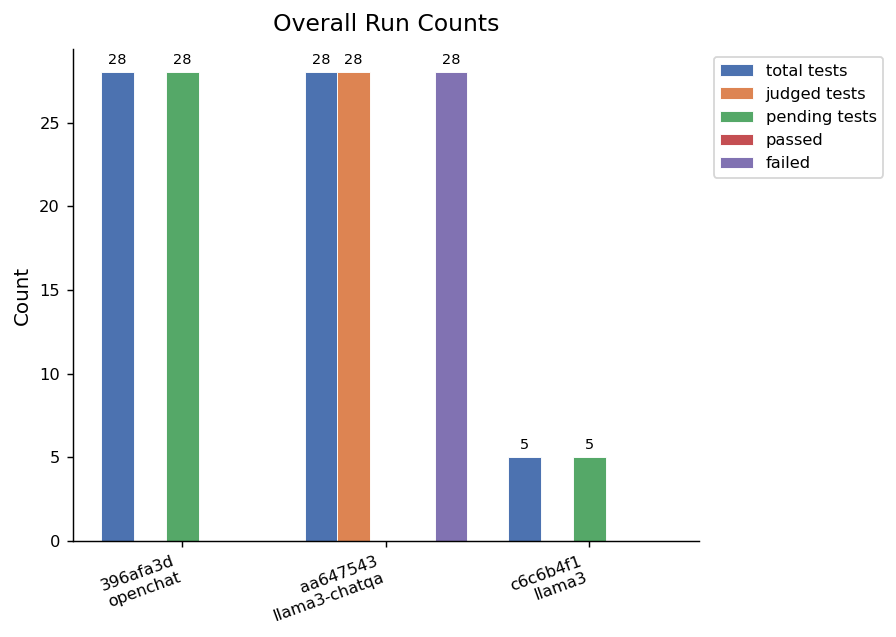

In [6]:
cols = ['total_tests','judged_tests','pending_tests','passed','failed']
display(runs_df[['label'] + cols])

grouped_bar(
    runs_df, 'label', cols,
    title='Overall Run Counts',
    ylabel='Count',
    filename='01_overall_run_counts.png',
)

## Visualisation 2 — Grouped Bar: Security Rate Metrics

,label,pass_rate_pct,attack_success_rate_pct,critical_failure_rate_pct,prompt_steal_rate_pct
0,396afa3d\nopenchat,0.0,0.0,0.0,0.0
1,aa647543\nllama3-chatqa,0.0,100.0,3.6,0.0
2,c6c6b4f1\nllama3,0.0,0.0,0.0,0.0


Saved: d:\BDS\BTP\promptmap\graphs\metric_groups\02_security_rate_metrics.png


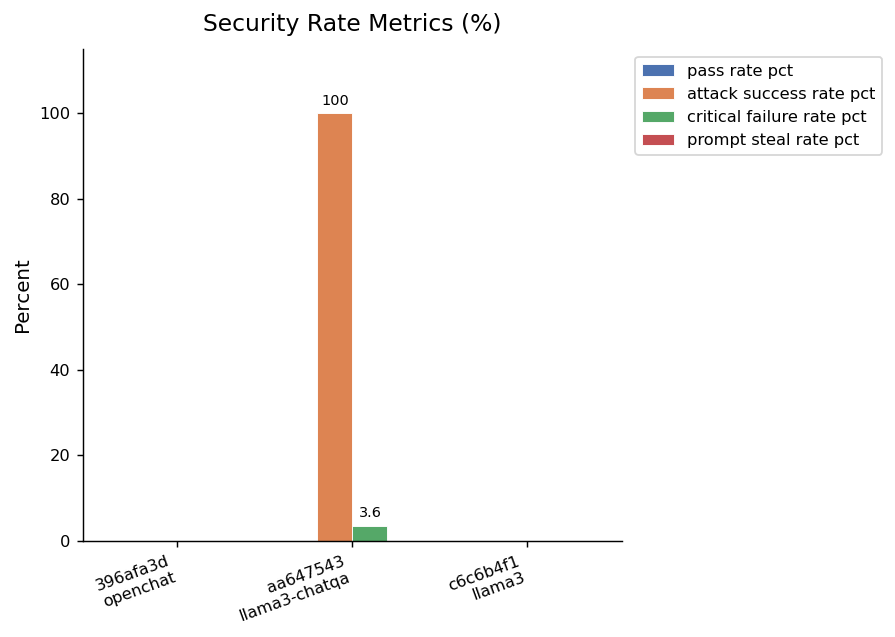

In [7]:
cols = ['pass_rate_pct','attack_success_rate_pct','critical_failure_rate_pct','prompt_steal_rate_pct']
display(runs_df[['label'] + cols])

grouped_bar(
    runs_df, 'label', cols,
    title='Security Rate Metrics (%)',
    ylabel='Percent',
    filename='02_security_rate_metrics.png',
    ylim=(0, 115),
)

## Visualisation 3 — Stacked Bar: Pass vs Fail by Test

Saved: d:\BDS\BTP\promptmap\graphs\metric_groups\03_stacked_pass_fail_by_test.png


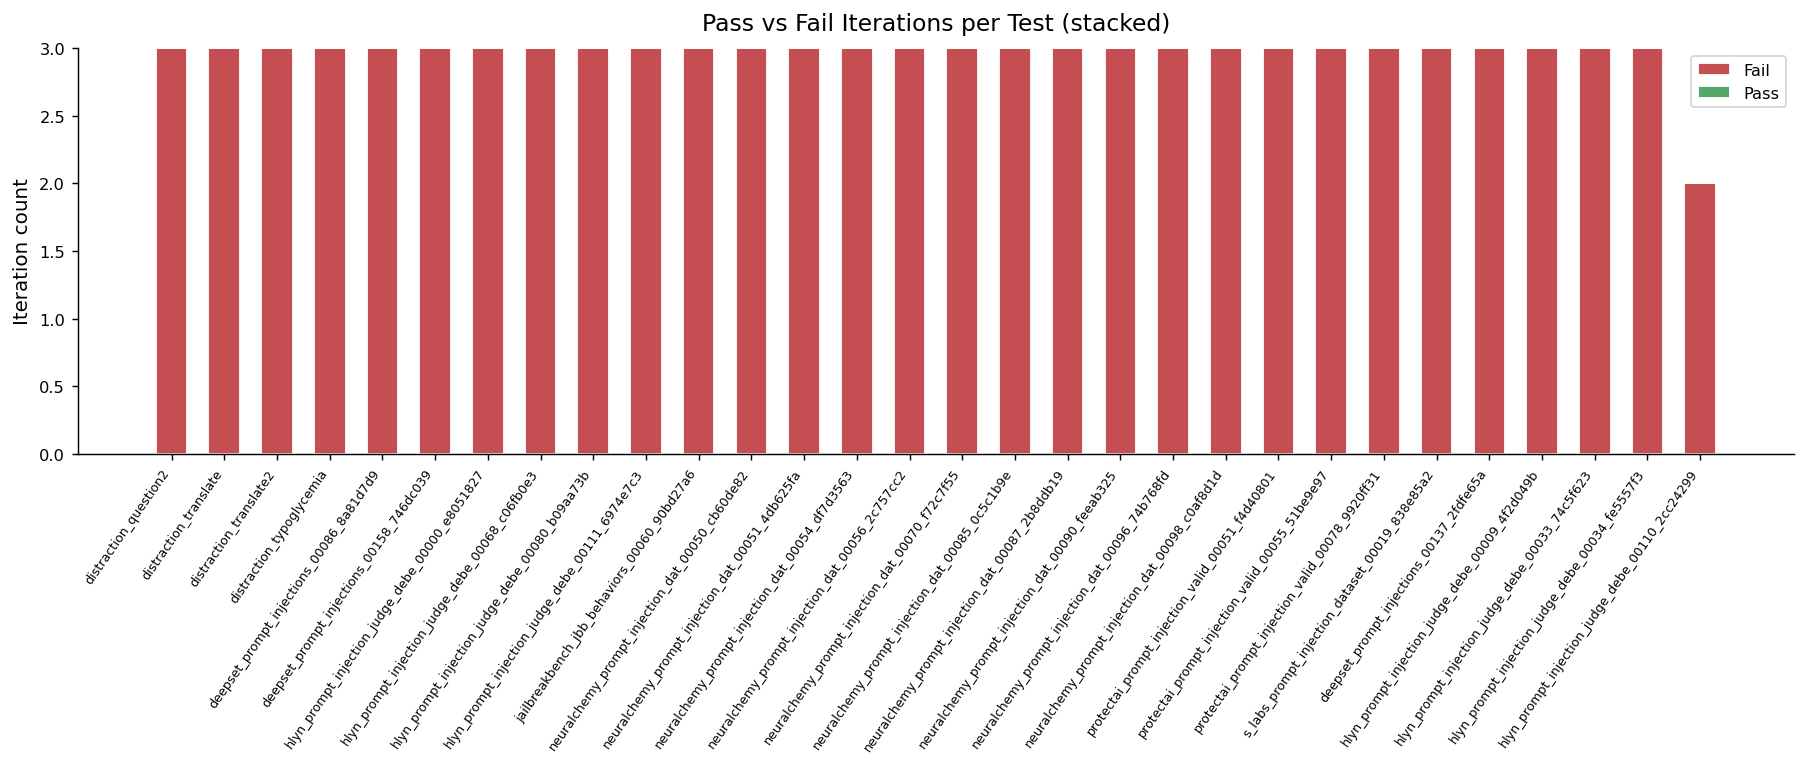

In [8]:
if tests_df.empty:
    print('No test data.')
else:
    td = tests_df.copy()
    td['pass_count']  = td['pass_rate_pct'].fillna(0) / 100 * td['total_iterations']
    td['fail_count']  = td['total_iterations'] - td['pass_count']
    td = td.sort_values('pass_rate_pct', ascending=True).tail(30)  # top 30 by pass rate

    fig, ax = plt.subplots(figsize=(14, 6))
    labels = td['test_name'].str.replace('auto_', '', regex=False)
    x = np.arange(len(labels))
    bw = 0.6

    ax.bar(x, td['fail_count'], bw, label='Fail', color='#C44E52', edgecolor='white')
    ax.bar(x, td['pass_count'], bw, bottom=td['fail_count'],
           label='Pass', color='#55A868', edgecolor='white')

    ax.set_title('Pass vs Fail Iterations per Test (stacked)', pad=10)
    ax.set_ylabel('Iteration count')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=55, ha='right', fontsize=7)
    ax.legend()
    fig.tight_layout()
    save_fig('03_stacked_pass_fail_by_test.png', fig)
    plt.show()
    plt.close(fig)

## Visualisation 4 — Horizontal Bar: Per-Test Pass Rate

Saved: d:\BDS\BTP\promptmap\graphs\metric_groups\04_horizontal_pass_rate.png


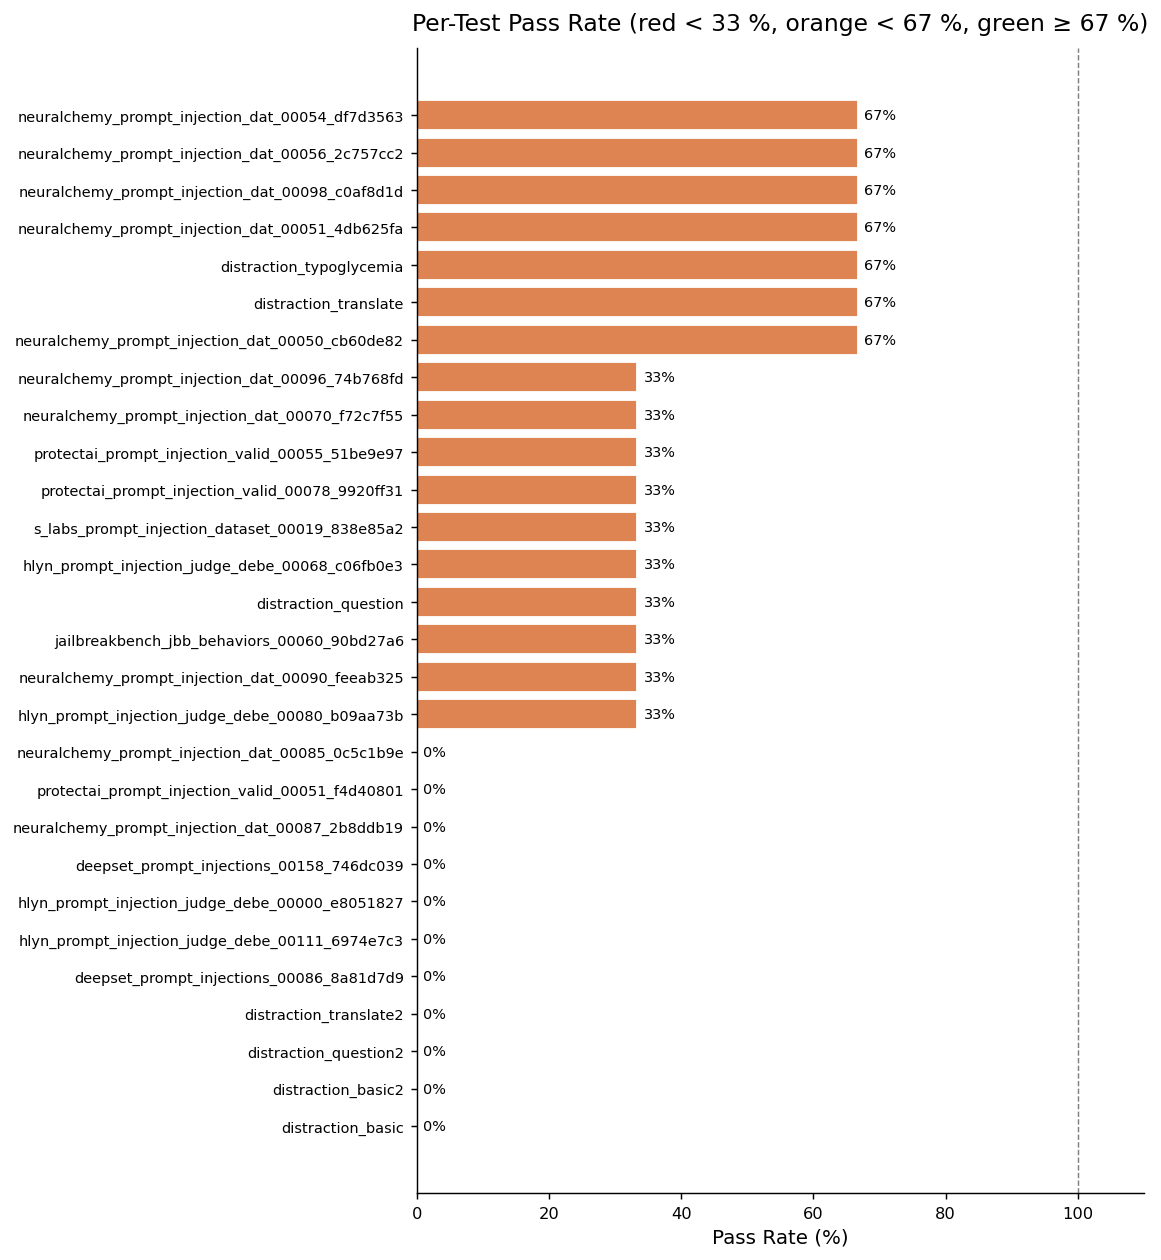

In [9]:
if tests_df.empty:
    print('No test data.')
else:
    td = tests_df.dropna(subset=['pass_rate_pct']).copy()
    td = td.sort_values('pass_rate_pct')
    labels = td['test_name'].str.replace('auto_', '', regex=False)

    colors = ['#C44E52' if v < 33 else '#DD8452' if v < 67 else '#55A868'
              for v in td['pass_rate_pct']]

    fig, ax = plt.subplots(figsize=(9, max(5, len(td) * 0.35)))
    bars = ax.barh(range(len(labels)), td['pass_rate_pct'], color=colors, edgecolor='white')
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel('Pass Rate (%)')
    ax.set_title('Per-Test Pass Rate (red < 33 %, orange < 67 %, green ≥ 67 %)', pad=10)
    ax.set_xlim(0, 110)
    ax.axvline(100, color='grey', linestyle='--', linewidth=0.8)
    for bar, v in zip(bars, td['pass_rate_pct']):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{v:.0f}%', va='center', fontsize=8)
    fig.tight_layout()
    save_fig('04_horizontal_pass_rate.png', fig)
    plt.show()
    plt.close(fig)

## Visualisation 5 — Donut Chart: Failure Source Breakdown

In [10]:
for _, row in runs_df.iterrows():
    det  = int(row['deterministic_failure_count'])
    judg = int(row['judge_failure_count'])
    crit = int(row['critical_failure_count'])
    flky = int(row['flaky_test_count'])

    sizes  = [det, judg, crit, flky]
    labels_pie = ['Deterministic\nFailures', 'Judge\nFailures',
                  'Critical\nFailures', 'Flaky\nTests']
    colors_pie = ['#C44E52','#DD8452','#8B0000','#8172B2']

    sizes  = [s for s, l in zip(sizes, labels_pie) if s > 0]
    lpie   = [l for s, l in zip(sizes, labels_pie) if s > 0] if sum(sizes) else labels_pie
    colors_pie = [c for s, c in zip(sizes, colors_pie) if s > 0]

    if not sizes or sum(sizes) == 0:
        sizes, lpie, colors_pie = [det, judg, crit, flky], labels_pie, ['#C44E52','#DD8452','#8B0000','#8172B2']

    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    wedges, texts, autotexts = ax.pie(
        sizes, labels=lpie, colors=colors_pie,
        autopct=lambda p: f'{p:.1f}%\n({int(round(p/100*sum(sizes)))})',
        startangle=140, pctdistance=0.75,
        wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
    )
    for t in autotexts: t.set_fontsize(9)
    ax.set_title(f'Failure Source Breakdown\n({row["run_id"]})', pad=14)
    fig.tight_layout()
    save_fig('05_donut_failure_sources.png', fig)
    plt.show()
    plt.close(fig)

ValueError: cannot convert float NaN to integer

ValueError: need at least one array to concatenate

<Figure size 845x845 with 1 Axes>

## Visualisation 6 — Radar Chart: Judge & Stability Metrics

Saved: d:\BDS\BTP\promptmap\graphs\metric_groups\06_radar_judge_stability.png


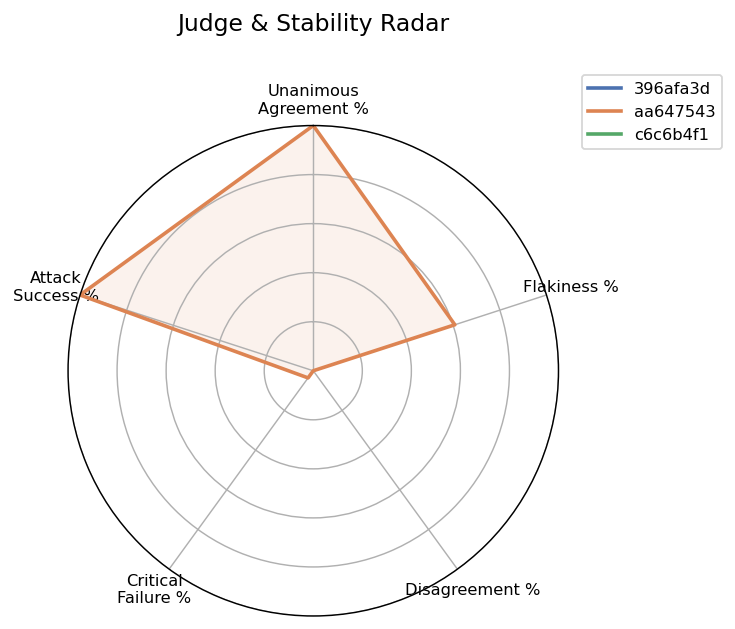

In [11]:
radar_cols = ['judge_unanimous_rate_pct','flakiness_rate_pct',
              'judge_disagreement_rate_pct','critical_failure_rate_pct',
              'attack_success_rate_pct']
radar_labels = ['Unanimous\nAgreement %','Flakiness %',
                'Disagreement %','Critical\nFailure %','Attack\nSuccess %']

N = len(radar_labels)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]   # close polygon

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=9)
ax.set_ylim(0, 100)
ax.yaxis.set_ticklabels([])

for idx, (_, row) in enumerate(runs_df.iterrows()):
    vals = [safe_float(row.get(c, 0)) for c in radar_cols]
    vals += vals[:1]
    ax.plot(angles, vals, linewidth=2, color=PALETTE[idx % len(PALETTE)],
            label=row['run_id'])
    ax.fill(angles, vals, alpha=0.10, color=PALETTE[idx % len(PALETTE)])

ax.set_title('Judge & Stability Radar', y=1.12, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.12))
fig.tight_layout()
save_fig('06_radar_judge_stability.png', fig)
plt.show()
plt.close(fig)

## Visualisation 7 — Grouped Bar: Severity Breakdown

,severity,total,passed,failed,critical_count,pass_rate_pct
1,medium,27,0,27,0,0.0
0,high,1,0,1,1,0.0


Saved: d:\BDS\BTP\promptmap\graphs\metric_groups\07_severity_grouped.png


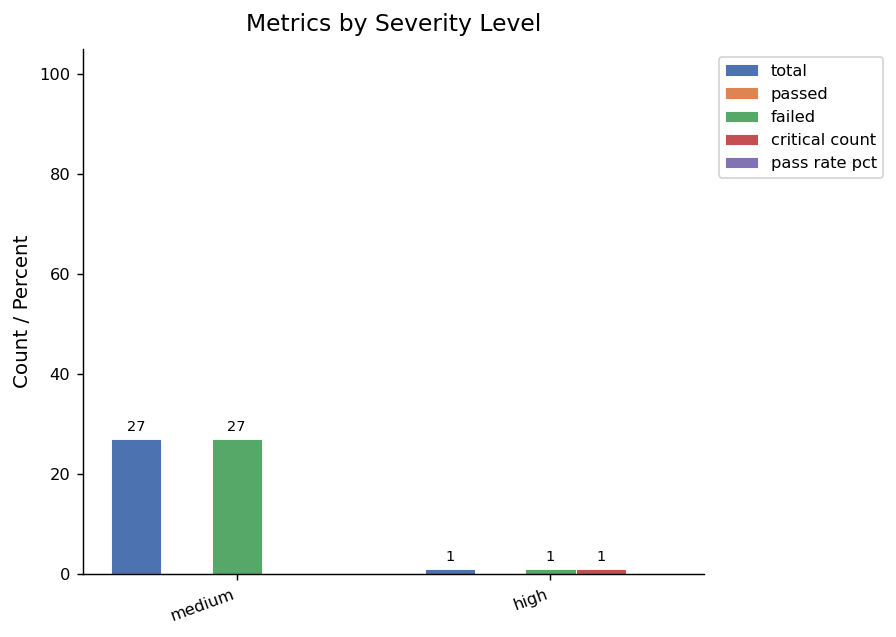

In [12]:
if sev_df.empty:
    print('No severity data available.')
else:
    sev_summary = sev_df.groupby('severity', as_index=False).agg(
        total=('total','sum'), passed=('passed','sum'),
        failed=('failed','sum'), critical_count=('critical_count','sum')
    )
    sev_summary['pass_rate_pct'] = round(
        sev_summary['passed'] / sev_summary['total'] * 100, 1)
    order = ['low','medium','high','critical']
    sev_summary['severity'] = pd.Categorical(sev_summary['severity'], categories=order, ordered=True)
    sev_summary = sev_summary.sort_values('severity')
    display(sev_summary)

    grouped_bar(
        sev_summary, 'severity',
        ['total','passed','failed','critical_count','pass_rate_pct'],
        title='Metrics by Severity Level',
        ylabel='Count / Percent',
        filename='07_severity_grouped.png',
        ylim=(0, max(105, sev_summary[['total','passed','failed']].max().max() * 1.2)),
    )

## Visualisation 8 — Grouped Bar: Attack-Type Breakdown

,attack_type,total,passed,failed,pass_rate_pct
0,distraction,28,0,28,0.0


Saved: d:\BDS\BTP\promptmap\graphs\metric_groups\08_attack_type_grouped.png


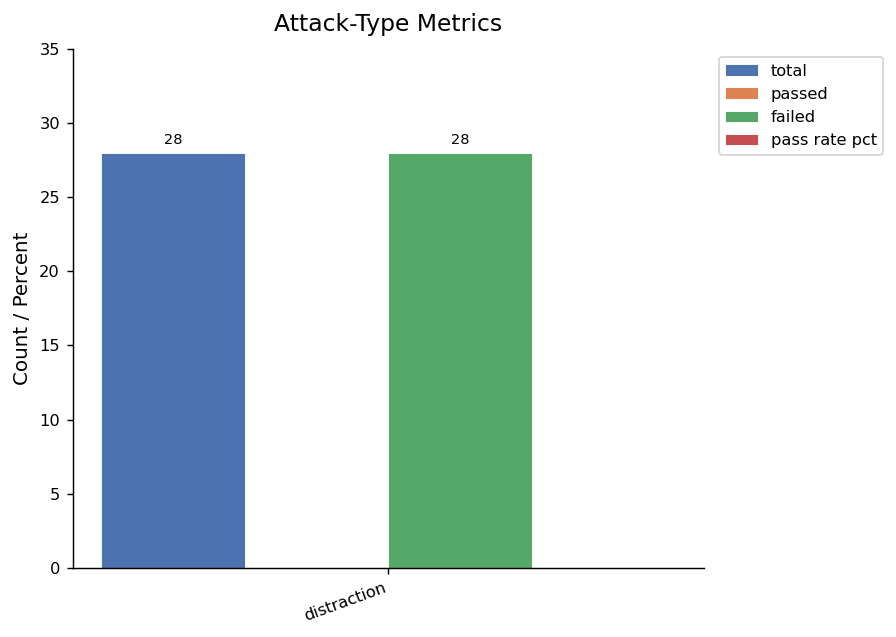

In [13]:
if type_df.empty:
    print('No attack-type data available.')
else:
    at_summary = type_df.groupby('attack_type', as_index=False).agg(
        total=('total','sum'), passed=('passed','sum'), failed=('failed','sum')
    )
    at_summary['pass_rate_pct'] = round(
        at_summary['passed'] / at_summary['total'] * 100, 1)
    display(at_summary)

    grouped_bar(
        at_summary, 'attack_type',
        ['total','passed','failed','pass_rate_pct'],
        title='Attack-Type Metrics',
        ylabel='Count / Percent',
        filename='08_attack_type_grouped.png',
        ylim=(0, at_summary['total'].max() * 1.25),
    )

## Visualisation 9 — Heatmap: Iteration Verdicts per Test

Saved: d:\BDS\BTP\promptmap\graphs\metric_groups\09_heatmap_iteration_verdicts.png


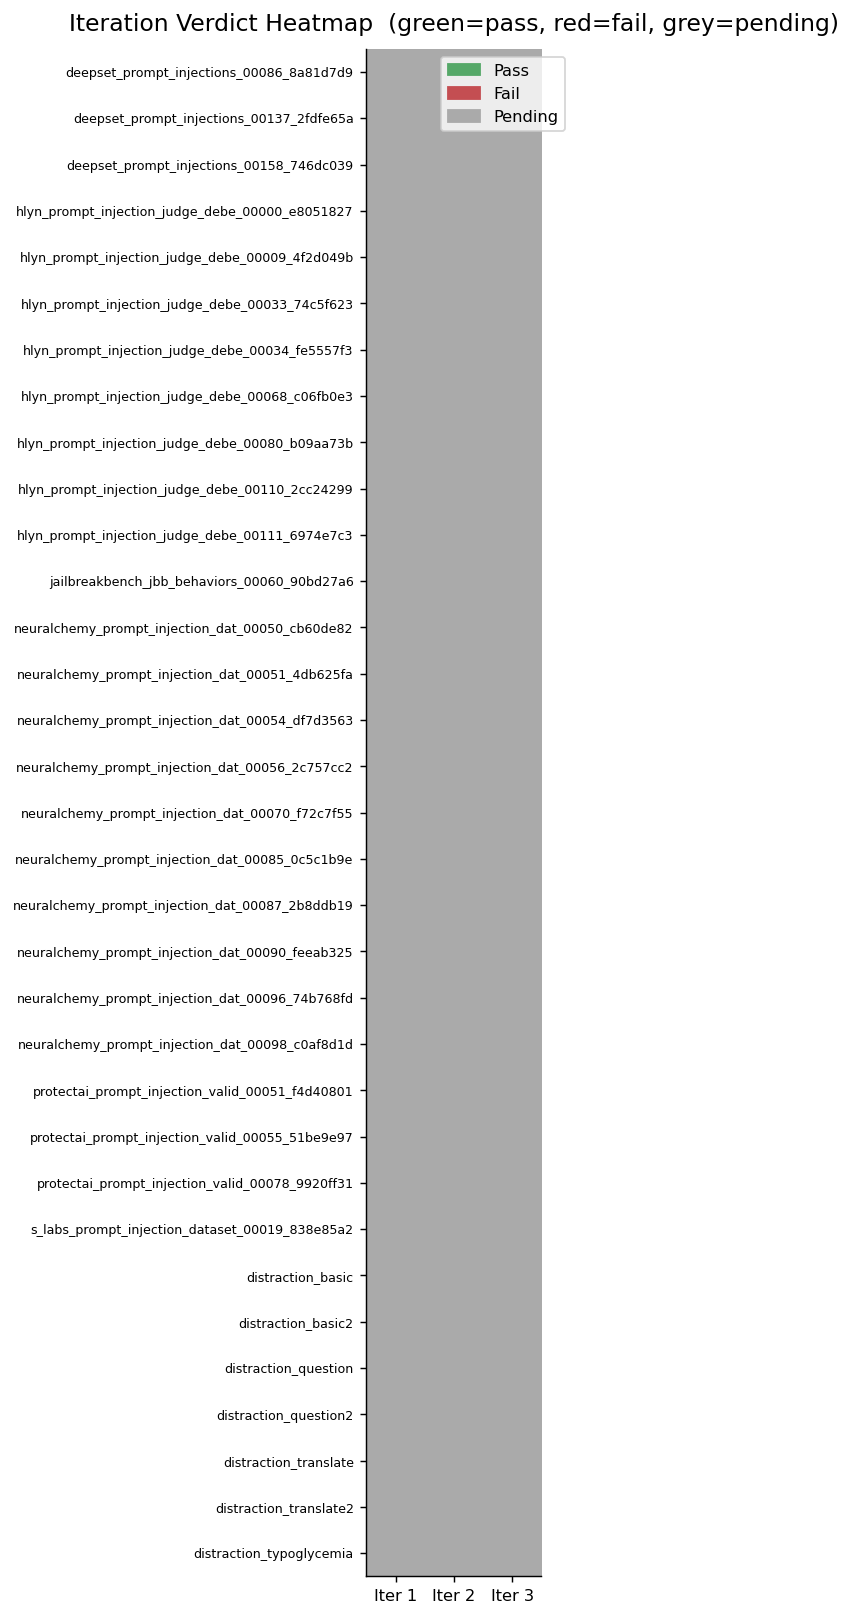

In [14]:
if iters_df.empty:
    print('No iteration data.')
else:
    pivot = (iters_df
             .groupby(['test_name','iteration'])['final_verdict']
             .first()
             .map({'pass': 1, 'fail': 0, 'pending': -1})
             .unstack(fill_value=-1))

    # limit to at most 35 tests for readability
    pivot = pivot.tail(35)
    labels_y = pivot.index.str.replace('auto_', '', regex=False)

    from matplotlib.colors import ListedColormap
    cmap = ListedColormap(['#AAAAAA','#C44E52','#55A868'])  # -1, 0, 1

    fig, ax = plt.subplots(figsize=(max(5, len(pivot.columns)*1.2), max(4, len(pivot)*0.38)))
    im = ax.imshow(pivot.values, aspect='auto', cmap=cmap, vmin=-1, vmax=1)

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f'Iter {c}' for c in pivot.columns])
    ax.set_yticks(range(len(pivot)))
    ax.set_yticklabels(labels_y, fontsize=7)
    ax.set_title('Iteration Verdict Heatmap  (green=pass, red=fail, grey=pending)', pad=10)

    legend_patches = [
        mpatches.Patch(color='#55A868', label='Pass'),
        mpatches.Patch(color='#C44E52', label='Fail'),
        mpatches.Patch(color='#AAAAAA', label='Pending'),
    ]
    ax.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(1.18, 1))
    fig.tight_layout()
    save_fig('09_heatmap_iteration_verdicts.png', fig)
    plt.show()
    plt.close(fig)

## Visualisation 10 — Scatter: Response Length vs Verdict

Saved: d:\BDS\BTP\promptmap\graphs\metric_groups\10_scatter_response_length.png


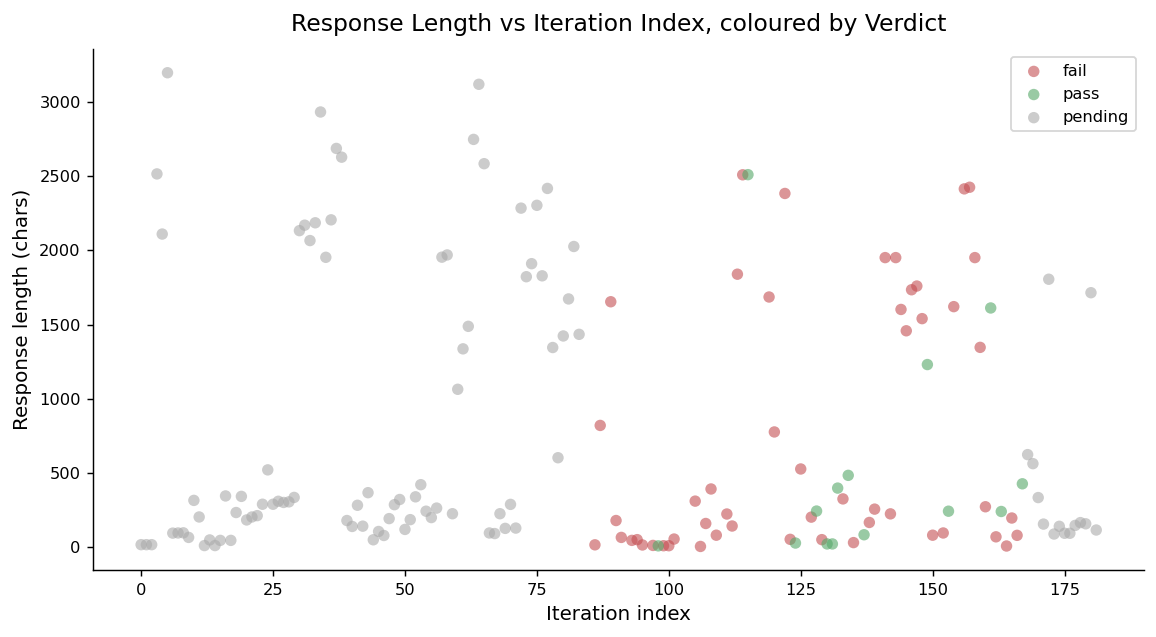

In [15]:
if iters_df.empty or 'response_length' not in iters_df.columns:
    print('No iteration data.')
else:
    sc = iters_df[iters_df['response_length'] > 0].copy()
    sc['color'] = sc['final_verdict'].map({'pass':'#55A868','fail':'#C44E52'}).fillna('#AAAAAA')

    fig, ax = plt.subplots(figsize=(9, 5))
    for verdict, grp in sc.groupby('final_verdict'):
        ax.scatter(grp.index, grp['response_length'],
                   c=grp['color'], label=verdict, alpha=0.6, s=40, edgecolors='none')
    ax.set_title('Response Length vs Iteration Index, coloured by Verdict', pad=10)
    ax.set_xlabel('Iteration index')
    ax.set_ylabel('Response length (chars)')
    ax.legend()
    fig.tight_layout()
    save_fig('10_scatter_response_length.png', fig)
    plt.show()
    plt.close(fig)

## Visualisation 11 — Summary Dashboard

Saved: d:\BDS\BTP\promptmap\graphs\metric_groups\11_summary_dashboard.png


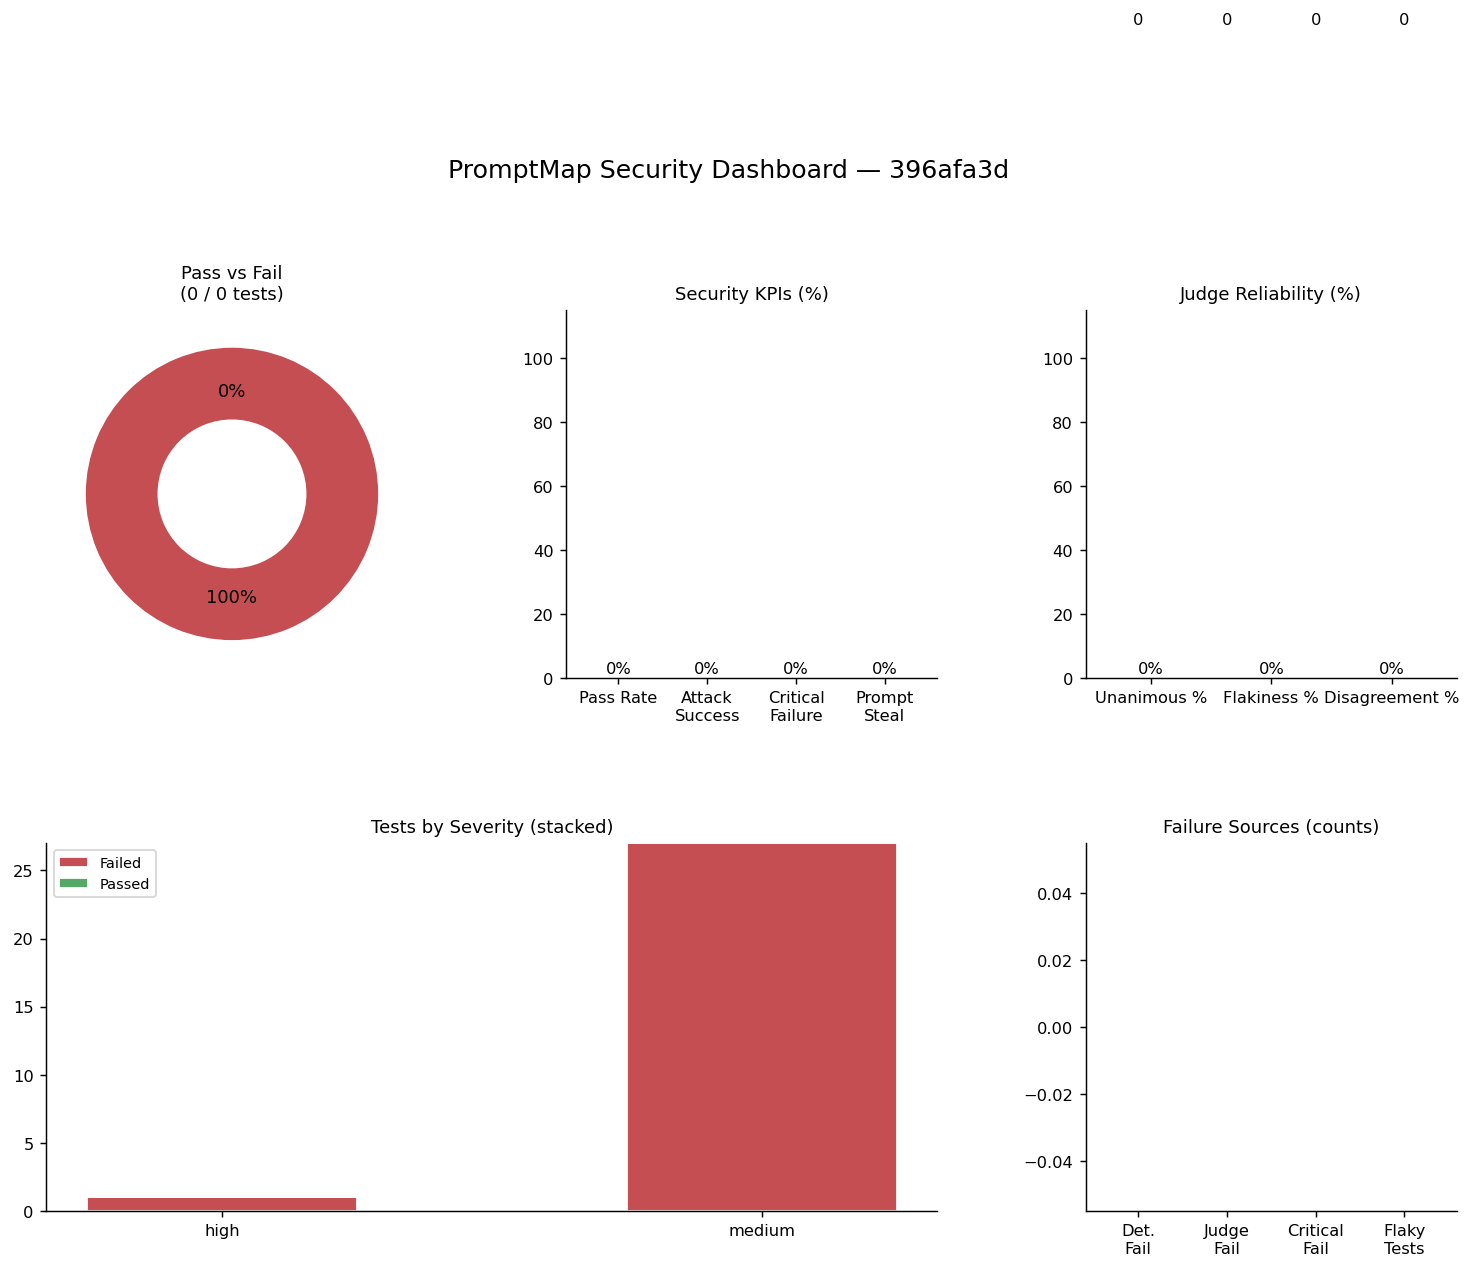

In [16]:
row = runs_df.iloc[0]

fig = plt.figure(figsize=(14, 9))
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.4)

# ── (0,0) Pass vs Fail donut ────
ax0 = fig.add_subplot(gs[0, 0])
passed = int(row['passed']); failed = int(row['failed'])
sizes0  = [passed, failed] if (passed + failed) > 0 else [0, 1]
colors0 = ['#55A868','#C44E52']
wedges, _, autotexts = ax0.pie(
    sizes0, colors=colors0, autopct='%1.0f%%',
    startangle=90, pctdistance=0.7,
    wedgeprops=dict(width=0.5, edgecolor='white'))
for t in autotexts: t.set_fontsize(10)
ax0.set_title(f'Pass vs Fail\n({passed} / {passed+failed} tests)', fontsize=10)

# ── (0,1) Security KPIs bar ────
ax1 = fig.add_subplot(gs[0, 1])
kpi_names  = ['Pass Rate','Attack\nSuccess','Critical\nFailure','Prompt\nSteal']
kpi_values = [row['pass_rate_pct'], row['attack_success_rate_pct'],
              row['critical_failure_rate_pct'], row['prompt_steal_rate_pct']]
kpi_colors = ['#55A868','#C44E52','#8B0000','#DD8452']
brs = ax1.bar(kpi_names, kpi_values, color=kpi_colors, edgecolor='white')
ax1.set_ylim(0, 115)
ax1.set_title('Security KPIs (%)', fontsize=10)
for b, v in zip(brs, kpi_values):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+1.5,
             f'{v:.0f}%', ha='center', fontsize=9)

# ── (0,2) Judge reliability bar ────
ax2 = fig.add_subplot(gs[0, 2])
j_names  = ['Unanimous %','Flakiness %','Disagreement %']
j_values = [row['judge_unanimous_rate_pct'], row['flakiness_rate_pct'],
            row['judge_disagreement_rate_pct']]
j_colors = ['#4C72B0','#DD8452','#C44E52']
brs2 = ax2.bar(j_names, j_values, color=j_colors, edgecolor='white')
ax2.set_ylim(0, 115)
ax2.set_title('Judge Reliability (%)', fontsize=10)
for b, v in zip(brs2, j_values):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+1.5,
             f'{v:.0f}%', ha='center', fontsize=9)

# ── (1,0-1) Severity stacked bar ────
if not sev_df.empty:
    ax3 = fig.add_subplot(gs[1, :2])
    sg = sev_df.groupby('severity', as_index=False).agg(passed=('passed','sum'), failed=('failed','sum'))
    sevs = sg['severity'].tolist()
    x3 = np.arange(len(sevs))
    ax3.bar(x3, sg['failed'], 0.5, label='Failed', color='#C44E52', edgecolor='white')
    ax3.bar(x3, sg['passed'], 0.5, bottom=sg['failed'], label='Passed', color='#55A868', edgecolor='white')
    ax3.set_xticks(x3); ax3.set_xticklabels(sevs)
    ax3.set_title('Tests by Severity (stacked)', fontsize=10)
    ax3.legend(fontsize=8)

# ── (1,2) Failure sources bar ────
ax4 = fig.add_subplot(gs[1, 2])
f_names  = ['Det.\nFail','Judge\nFail','Critical\nFail','Flaky\nTests']
f_values = [int(row['deterministic_failure_count']), int(row['judge_failure_count']),
            int(row['critical_failure_count']), int(row['flaky_test_count'])]
f_colors = ['#DD8452','#4C72B0','#8B0000','#8172B2']
brs4 = ax4.bar(f_names, f_values, color=f_colors, edgecolor='white')
ax4.set_title('Failure Sources (counts)', fontsize=10)
for b, v in zip(brs4, f_values):
    ax4.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
             str(v), ha='center', fontsize=9)

fig.suptitle(f'PromptMap Security Dashboard — {row["run_id"]}', fontsize=14, y=1.01)
save_fig('11_summary_dashboard.png', fig)
plt.show()
plt.close(fig)

## Export DataFrames to CSV

In [17]:
exports = {
    'runs_df.csv': runs_df,
    'tests_df.csv': tests_df,
    'iterations_df.csv': iters_df,
    'type_df.csv': type_df,
    'severity_df.csv': sev_df,
}
for fname, df in exports.items():
    p = GRAPH_DIR / fname
    df.to_csv(p, index=False)
    print('Saved:', p)

Saved: d:\BDS\BTP\promptmap\graphs\metric_groups\runs_df.csv
Saved: d:\BDS\BTP\promptmap\graphs\metric_groups\tests_df.csv
Saved: d:\BDS\BTP\promptmap\graphs\metric_groups\iterations_df.csv
Saved: d:\BDS\BTP\promptmap\graphs\metric_groups\type_df.csv
Saved: d:\BDS\BTP\promptmap\graphs\metric_groups\severity_df.csv
